# OCR with Pytesseract

In this notebook, you'll work with pytesseract to extract some parts of an invoice image.

## Step 1: Install Dependencies

For this, we'll need both the Python Imaging Library and pytesseract.

In [1]:
!pip install pillow pytesseract -q

# Step 2: Import Libraries

In [2]:
from PIL import Image
import pytesseract
from IPython.display import display

## Step 3: Read in an Invoice Image

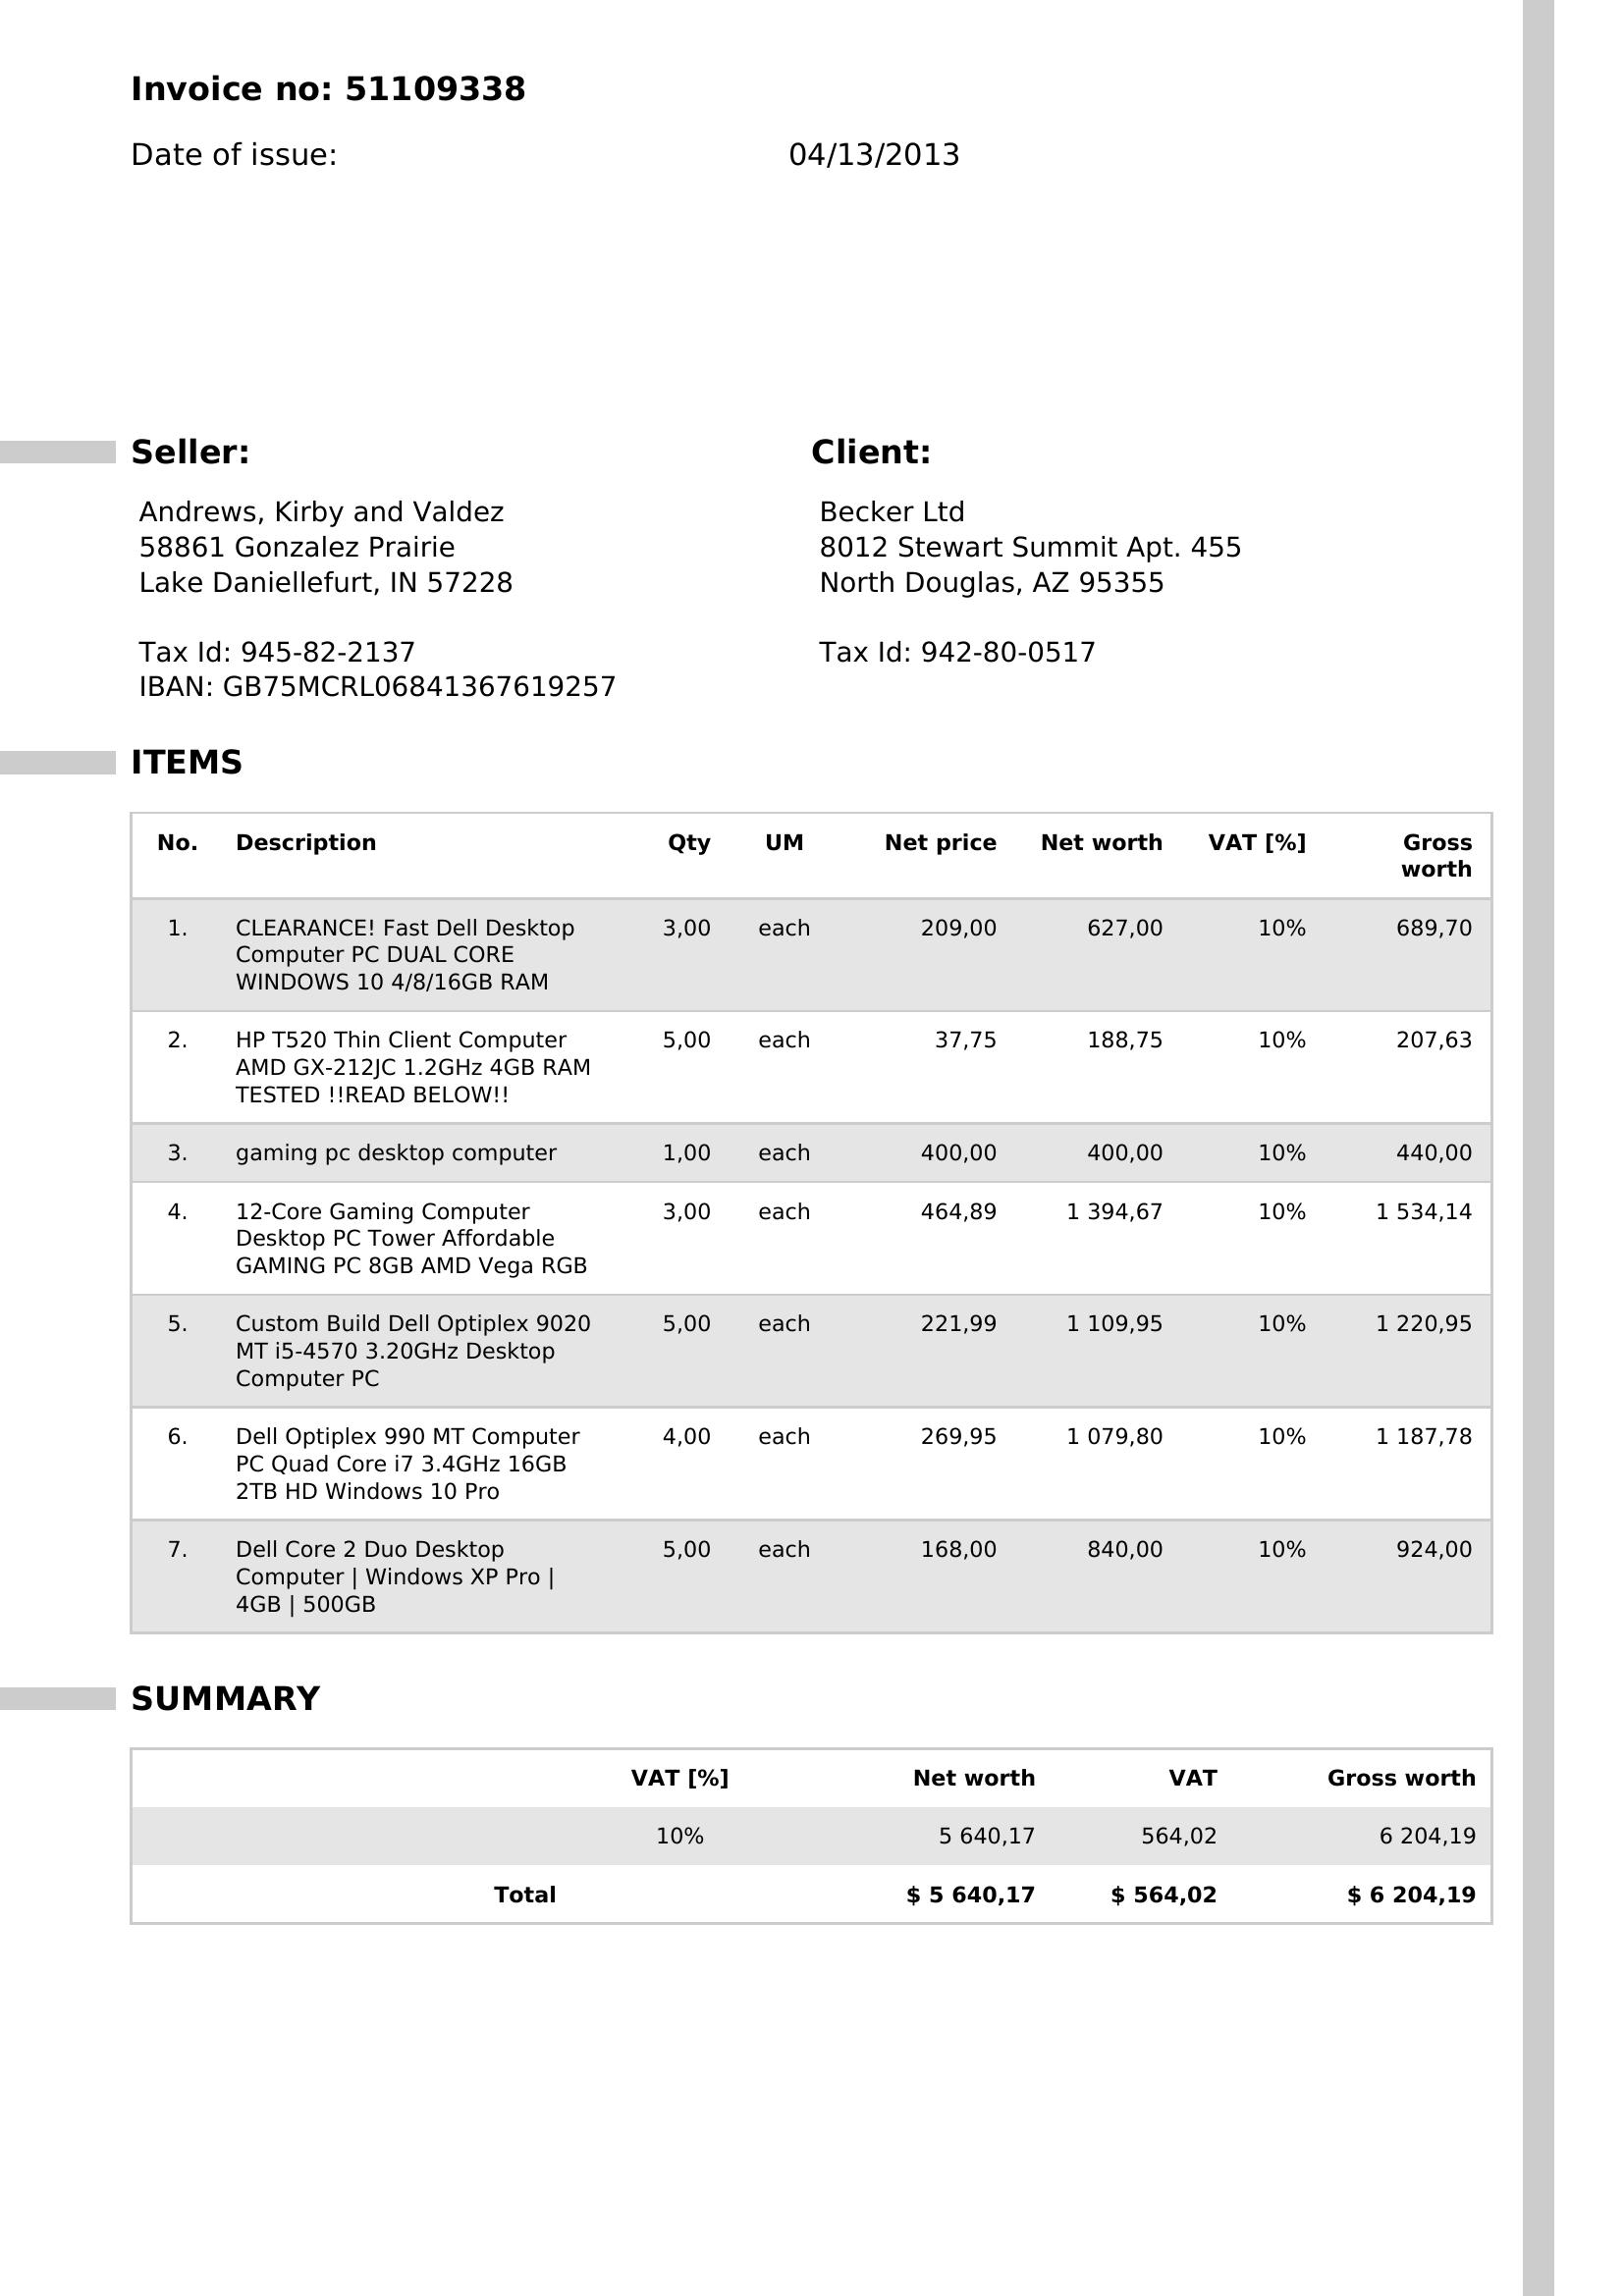

In [5]:
INVOICE_FILEPATH = './data/batch1-0001.jpg'

image = Image.open(INVOICE_FILEPATH)
display(image)

## Step 4: Extract Text of Invoice Image

We can start by seeing the overall text that pytesseract extracts.

In [6]:
invoice_text = pytesseract.image_to_string(image)
print(invoice_text)

Invoice no: 51109338

Date of issue:

Seller:

Andrews, Kirby and Valdez
58861 Gonzalez Prairie
Lake Daniellefurt, IN 57228

Tax Id: 945-82-2137
IBAN: GB75MCRL06841367619257

ITEMS
No. Description Qty
ils CLEARANCE! Fast Dell Desktop 3,00

Computer PC DUAL CORE
WINDOWS 10 4/8/16GB RAM

2. HP T520 Thin Client Computer 5,00
AMD GX-212JC 1.2GHz 4GB RAM
TESTED !!READ BELOW!!

3: gaming pc desktop computer 1,00

4. 12-Core Gaming Computer 3,00
Desktop PC Tower Affordable
GAMING PC 8GB AMD Vega RGB

Se Custom Build Dell Optiplex 9020 5,00
MT i5-4570 3.20GHz Desktop
Computer PC

6. Dell Optiplex 990 MT Computer 4,00
PC Quad Core i7 3.4GHz 16GB
2TB HD Windows 10 Pro

Ee Dell Core 2 Duo Desktop 5,00
Computer | Windows XP Pro |
4GB | 500GB
SUMMARY
VAT [%]
10%
Total

04/13/2013

UM

eacl

eac

eac

eac

eac

eac

eac

h

 

Client:
Becker Ltd

8012 Stewart Summit Apt. 455
North Douglas, AZ 95355

Tax Id: 942-80-0517

Net price

209,00

37,75

400,00

464,89

221,99

269,95

168,00

Net worth
5 64

## Step 5: Try a Different Page Segmentation Mode

By default, pytesseract attempts to divide the invoice into blocks. However, in certain cases, we might want it to just read the image left-to-right.

```
# This is formatted as code
```




In [7]:
invoice_text = pytesseract.image_to_string(image, config="--psm 6")
print(invoice_text)

Invoice no: 51109338
Date of issue: 04/13/2013
Seller: Client:
Andrews, Kirby and Valdez Becker Ltd
58861 Gonzalez Prairie 8012 Stewart Summit Apt. 455
Lake Daniellefurt, IN 57228 North Douglas, AZ 95355
Tax Id: 945-82-2137 Tax Id: 942-80-0517
IBAN: GB75MCRL06841367619257
ITEMS
No. Description Qty UM Net price Net worth VAT [%] Gross
worth
1. CLEARANCE! Fast Dell Desktop 3,00 each 209,00 627,00 10% 689,70
Computer PC DUAL CORE
WINDOWS 10 4/8/16GB RAM
2. HP T520 Thin Client Computer 5,00 each 37,75 188,75 10% 207,63
AMD GX-212JC 1.2GHz 4GB RAM
TESTED !!READ BELOW!!
3: gaming pc desktop computer 1,00 each 400,00 400,00 10% 440,00
4. 12-Core Gaming Computer 3,00 each 464,89 1 394,67 10% 1 534,14
Desktop PC Tower Affordable
GAMING PC 8GB AMD Vega RGB
DS Custom Build Dell Optiplex 9020 5,00 each 221,99 1 109,95 10% 1 220,95
MT i5-4570 3.20GHz Desktop
Computer PC
6. Dell Optiplex 990 MT Computer 4,00 each 269,95 1 079,80 10% 1 187,78
PC Quad Core i7 3.4GHz 16GB
2TB HD Windows 10 Pro
hs Dell 

## Step 6: Extract Text as a DataFrame

In order to more easily navigate the invoice text contents, we can extract it as a pandas DataFrame.

In [8]:
invoice_df = pytesseract.image_to_data(image, output_type=pytesseract.Output.DATAFRAME, config="--psm 3")
invoice_df

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
0,1,1,0,0,0,0,0,0,1654,2339,-1,NaN
1,2,1,1,0,0,0,136,77,398,26,-1,NaN
2,3,1,1,1,0,0,136,77,398,26,-1,NaN
3,4,1,1,1,1,0,136,77,398,26,-1,NaN
4,5,1,1,1,1,1,136,77,130,26,96,Invoice
...,...,...,...,...,...,...,...,...,...,...,...,...
436,3,1,67,1,0,0,1373,1921,129,20,-1,NaN
437,4,1,67,1,1,0,1373,1921,129,20,-1,NaN
438,5,1,67,1,1,1,1373,1921,13,20,92,$
439,5,1,67,1,1,2,1396,1921,13,17,96,6


Now, we can make use of the structure.

We can take advantage of the levels to access different parts of the hierarchy. For example, we can look at the blocks by filtering to level 2.

In [10]:
blocks = invoice_df[invoice_df['level'] == 2]
blocks

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
1,2,1,1,0,0,0,136,77,398,26,-1,NaN
7,2,1,2,0,0,0,136,145,205,23,-1,NaN
13,2,1,3,0,0,0,135,447,117,25,-1,NaN
17,2,1,4,0,0,0,142,510,379,96,-1,NaN
33,2,1,5,0,0,0,141,653,485,56,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
416,2,1,63,0,0,0,1403,1454,95,20,-1,NaN
421,2,1,64,0,0,0,1423,1569,76,20,-1,NaN
425,2,1,65,0,0,0,1353,1802,149,17,-1,NaN
430,2,1,66,0,0,0,1406,1861,96,20,-1,NaN


We can inspect the individual blocks by using the dimension columns.

Try changing the block_to_crop to see how the invoice image was subdivided.

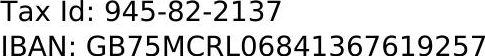

In [14]:
block_to_crop = 5
block_data = blocks[blocks['block_num'] == block_to_crop]

# Bounding box for the block
left = block_data['left'].values[0]
top = block_data['top'].values[0]
right = left + block_data['width'].values[0]
bottom = top + block_data['height'].values[0]

cropped_image = image.crop((left, top, right, bottom))
display(cropped_image)

## Step 7: Extract Different Invoice Components

Let's look at an example of how to locate an invoice component. We'll focus on the invoice number.

We can find the line block and line that contains the text "Invoice". We know that the invoice number is contained at the end of this line.

In [16]:
# Text is contained at level 5
text_df = invoice_df[invoice_df['level'] == 5]

# Filter to the row corresponding to the word "Invoice"
text_df[text_df['text'].str.contains('Invoice')]

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
4,5,1,1,1,1,1,136,77,130,26,96,Invoice


Once we find the correct row, we can grab the block_num and line_num.

In [17]:
block_num, line_num = text_df[text_df['text'].str.contains('Invoice')][['block_num', 'line_num']].values[0].tolist()

Then we can get the last word on that same line.

In [18]:
(
    text_df
    .loc[text_df['block_num'] == block_num]
    .loc[text_df['line_num'] == line_num]
    .nlargest(1, 'word_num')
    ['text'].values[0]
)

'51109338'

## Your Turn: Extract Other Components

Your task is to try to use a similar strategy to extract other parts of the invoice.

1. Extract the IBAN.
2. Extract the date of issue. Hint: You may need to adjust the psm in order to get the date.
3. Extract the invoice total (the gross worth).
4. **Challenge:** Extract the seller name and address.
5. **Challenge:** Extract the client name and address.